## Holiday Package Prediciton

### 1) Problem statement.
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base.
One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information.
The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being.
However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.
### 2) Data Collection.
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction
The data consists of 20 column and 4888 rows.

In [2]:
## importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [3]:
df= pd.read_csv("Travel.csv")
df.head(15)

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,3.0,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0
6,200006,0,59.0,Self Enquiry,1,9.0,Small Business,Female,2,2.0,Basic,5.0,Divorced,5.0,1,2,1,1.0,Executive,17670.0
7,200007,0,30.0,Self Enquiry,1,30.0,Salaried,Male,3,3.0,Basic,3.0,Married,2.0,0,2,0,1.0,Executive,17693.0
8,200008,0,38.0,Company Invited,1,29.0,Salaried,Male,2,4.0,Standard,3.0,Unmarried,1.0,0,3,0,0.0,Senior Manager,24526.0
9,200009,0,36.0,Self Enquiry,1,33.0,Small Business,Male,3,3.0,Deluxe,3.0,Divorced,7.0,0,3,1,0.0,Manager,20237.0


### Data cleaning
1. handling missing values
2. handling duplicate values
3. check data type 
4. understand dataset


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [5]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [6]:
# 
# fill nan vlaues

# handle age null values
df['Age'].fillna(df['Age'].mean() , inplace= True)

#handle TypeofContact null values
df['TypeofContact'].fillna('Self Enquiry', inplace= True)

# handle DurationOfPitch null values
df['DurationOfPitch'].fillna(df['DurationOfPitch'].backfill() , inplace=True)

# handle NumberofFollowups
df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].mode()[0] , inplace= True)

# handle PreferredPropertyStar null value 
df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].backfill() , inplace= True)

# handle NumberOfTrips null value
df.loc[(df['TypeofContact'] == 'Self Enquiry') & (df['NumberOfTrips'].isna()), 'NumberOfTrips'] = 0
df['NumberOfTrips'].fillna(df['NumberOfTrips'].mode()[0] , inplace= True)

# handle NumberOfChildrenVisiting null value
df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].mode()[0] , inplace= True)

# handle MonthlyIncome null value
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median() , inplace= True)





In [7]:
df['Gender'].value_counts()
# it show the mistake in female spelling

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [8]:
# correct the spelling of female
df['Gender'].replace('Fe Male' , 'Female' , inplace=True)
df['Gender'].value_counts()


Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [9]:
df['TypeofContact'].value_counts()


TypeofContact
Self Enquiry       3469
Company Invited    1419
Name: count, dtype: int64

In [10]:
df['Occupation'].value_counts()


Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64

In [11]:

df['ProductPitched'].value_counts()


ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64

In [12]:
df['MaritalStatus'].value_counts()


MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [13]:
df['Designation'].value_counts()


Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64

## Feature Engineering



### Feature Extraction

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4888 non-null   float64
 3   TypeofContact             4888 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4888 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4888 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4888 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4888 non-null   float64
 14  Passport

In [15]:
df

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.000000,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.000000,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.000000,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.000000,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,37.622265,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,204883,1,49.000000,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,204884,1,28.000000,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0
4885,204885,1,52.000000,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,204886,1,19.000000,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0


In [16]:
# because the id not useable in ML model 
df.drop(['CustomerID'], axis= 1, inplace = True)

In [17]:
# create new column for feature
df['TotalVisiting'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df.drop(columns=['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'], axis=1, inplace=True)

In [18]:
df.isnull().sum()

ProdTaken                 0
Age                       0
TypeofContact             0
CityTier                  0
DurationOfPitch           0
Occupation                0
Gender                    0
NumberOfFollowups         0
ProductPitched            0
PreferredPropertyStar     0
MaritalStatus             0
NumberOfTrips             0
Passport                  0
PitchSatisfactionScore    0
OwnCar                    0
Designation               0
MonthlyIncome             0
TotalVisiting             0
dtype: int64

## Train Test Split And Model Training

In [19]:
x = df.drop(['ProdTaken'] , axis = 1)
y = df['ProdTaken']

In [20]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y ,train_size= 0.80 , random_state=42)

In [21]:
# Create Column Transformer with 3 types of transformers
cat_features = x.select_dtypes(include="object").columns
num_features = x.select_dtypes(exclude="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')

preprocessor = ColumnTransformer(
    [
         ("OneHotEncoder", oh_transformer, cat_features),
          ("StandardScaler", numeric_transformer, num_features)
    ]
)

In [22]:
## applying Trnsformation in training(fit_transform)
x_train=preprocessor.fit_transform(x_train)

In [23]:
y_test

144     0
79      0
2098    0
4738    0
2858    1
       ..
2908    0
2059    1
4872    1
843     0
2572    0
Name: ProdTaken, Length: 978, dtype: int64

In [22]:
x_train

array([[ 1.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.38224537, -0.77415132],
       [ 1.        ,  0.        ,  1.        , ...,  0.78296635,
        -0.4597992 ,  0.64361526],
       [ 1.        ,  1.        ,  0.        , ...,  0.78296635,
        -0.24519557, -0.06526803],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.36057591,  0.64361526],
       [ 1.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.25279888,  0.64361526],
       [ 0.        ,  0.        ,  1.        , ..., -1.2771941 ,
        -1.08251091, -1.48303461]], shape=(3910, 27))

In [23]:
# pd.DataFrame(x_train).isnull().sum()

In [24]:
## applying Trnsformation in training(fit_transform)
x_test=preprocessor.transform(x_test)

In [25]:
x_test

array([[ 0.        ,  0.        ,  0.        , ..., -1.2771941 ,
        -0.73751038, -0.77415132],
       [ 1.        ,  0.        ,  0.        , ..., -1.2771941 ,
        -0.6704111 , -0.06526803],
       [ 1.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.4208322 , -0.77415132],
       ...,
       [ 0.        ,  1.        ,  0.        , ...,  0.78296635,
         0.69001249,  0.64361526],
       [ 1.        ,  0.        ,  0.        , ...,  0.78296635,
        -0.22827818, -0.77415132],
       [ 1.        ,  1.        ,  0.        , ...,  0.78296635,
        -0.44611323,  2.06138184]], shape=(978, 27))

## Gradient Boosting classification

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay,\
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [27]:
models={
    "Logisitic Regression":LogisticRegression(),
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boost":GradientBoostingClassifier(),
    "Adaboost" : AdaBoostClassifier(),
    "XGBoost" : XGBClassifier()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

Logisitic Regression
Model performance for Training set
- Accuracy: 0.8463
- F1 score: 0.8215
- Precision: 0.6963
- Recall: 0.3114
- Roc Auc Score: 0.6401
----------------------------------
Model performance for Test set
- Accuracy: 0.8364
- F1 score: 0.8109
- Precision: 0.6782
- Recall: 0.3089
- Roc Auc Score: 0.6367


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.8998
- F1 score: 0.8979
- Precision: 0.7688
- Recall: 0.6963
- Roc Auc Score: 0.8228


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9243
- F1 score: 0.9184
- Precision: 0.9535
- Recall: 0.6440
- Roc Auc Score: 0.8182


Gradient Boost
Model performance for Training se

In [28]:
## Hyperparameter Training
rf_params = {
            'criterion' : ["gini", "entropy", "log_loss"],
            "max_depth": [5, 8, 15, None, 10],
            "max_features": [5, 7, "auto", 8],
            "min_samples_split": [2, 8, 15, 20],
            "n_estimators": [100, 200, 500, 1000]}

adaboost_params ={
    'n_estimators' :  [50,60,70,80,90],
    'algorithm':['SAMME' , 'SAMME.R']
}
gradientBoost_param = {
    'loss' : ['log_loss', 'exponential'],
    'learning_rate':[0.1,1,10,100],
    'n_estimators':[1,100,1000,500],
    'criterion' : ['friedman_mse', 'squared_error'],
    
}

xgboost_param = {
    'n_estimators': [100, 500, 1000],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

In [29]:
# Models list for Hyperparameter tuning
# tuple hold name_model , model , parameter
randomcv_models = [
                   ("RF", RandomForestClassifier(), rf_params),
                   ("Adaboost" , AdaBoostClassifier() , adaboost_params),
                   ("GradinentBoost" , GradientBoostingClassifier(), gradientBoost_param),
                   ("XGBoost", XGBClassifier(), xgboost_param)
                   
                   ]

In [30]:
from sklearn.model_selection import RandomizedSearchCV
model_param = {}
for name , model  , params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                param_distributions= params,
                                n_iter=100,
                                cv=3,
                                verbose=2,
                                n_jobs=-1)
    random.fit(x_train , y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print('------------Best parameter-----------')
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Fitting 3 folds for each of 100 candidates, totalling 300 fits
------------Best parameter-----------
{'n_estimators': 500, 'min_samples_split': 2, 'max_features': 5, 'max_depth': None, 'criterion': 'gini'}
------------Best parameter-----------
{'n_estimators': 90, 'algorithm': 'SAMME'}
------------Best parameter-----------
{'n_estimators': 1000, 'loss': 'exponential', 'learning_rate': 1, 'criterion': 'squared_error'}
------------Best parameter-----------
{'subsample': 1.0, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.3, 'colsample_bytree': 0.9}


In [32]:
models={
    
    "Random Forest":RandomForestClassifier(n_estimators=1000,min_samples_split=2,
                                          max_features=8,max_depth=None),
    "Adaboost" :AdaBoostClassifier(n_estimators=90 , algorithm='SAMME'),
    "GradientBoost" : GradientBoostingClassifier(n_estimators=1000 , loss='exponential' ,  learning_rate=1 , criterion='friedman_mse'),
    "XGBoost" : XGBClassifier(n_estimators=500, max_depth=10, learning_rate=0.3, subsample=1.0, colsample_bytree=0.9, random_state=42)
                                
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9274
- F1 score: 0.9225
- Precision: 0.9412
- Recall: 0.6702
- Roc Auc Score: 0.8300


Adaboost
Model performance for Training set
- Accuracy: 0.8486
- F1 score: 0.8176
- Precision: 0.7665
- Recall: 0.2702
- Roc Auc Score: 0.6257
----------------------------------
Model performance for Test set
- Accuracy: 0.8364
- F1 score: 0.7995
- Precision: 0.7627
- Recall: 0.2356
- Roc Auc Score: 0.6089


GradientBoost
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9254
- F1 score: 0.9233
- Precision: 0.8554
- Recall: 0.7435
- Roc Auc Score: 0.8565


XGBoost
Model performance for Training set
- Accuracy: 1.000

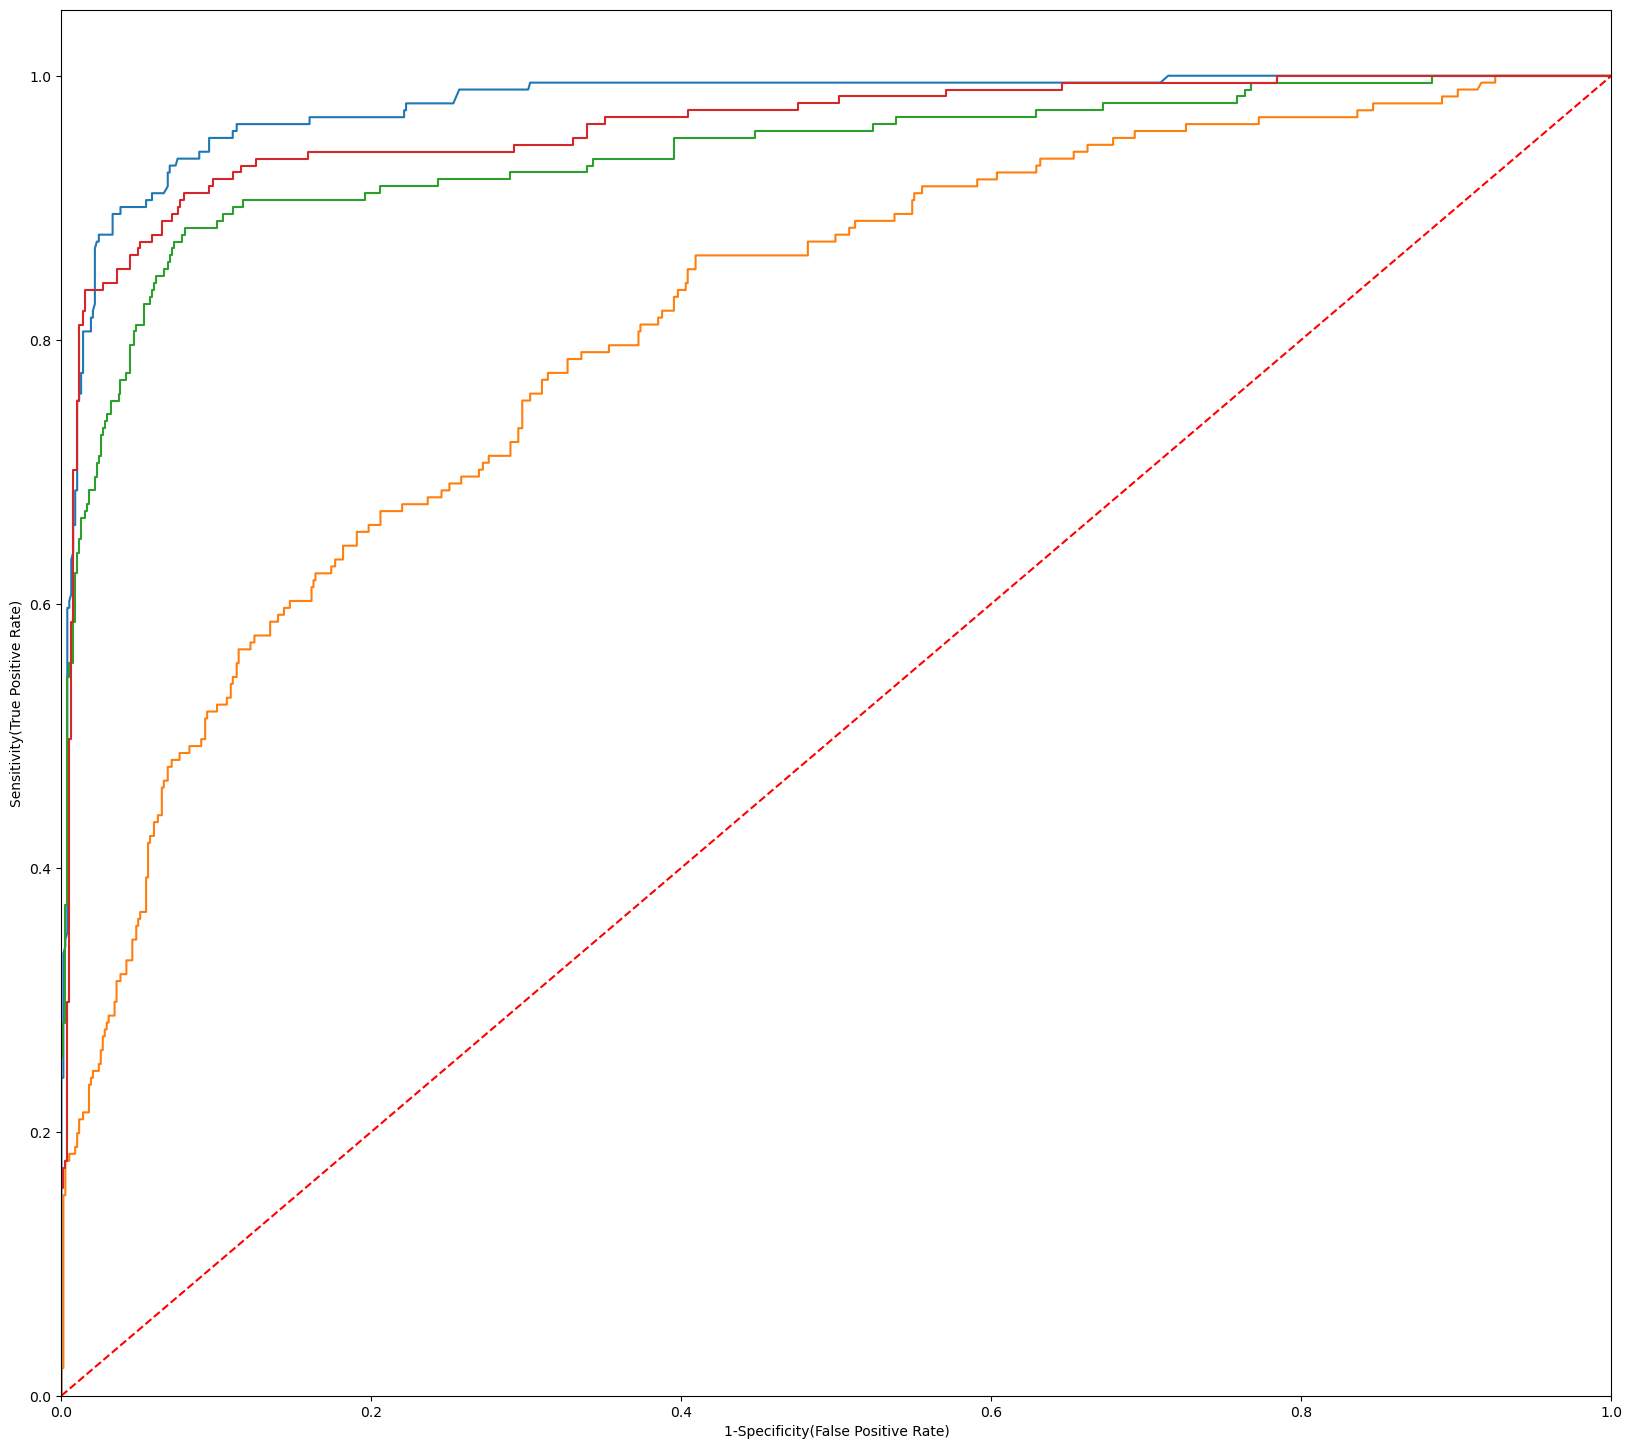

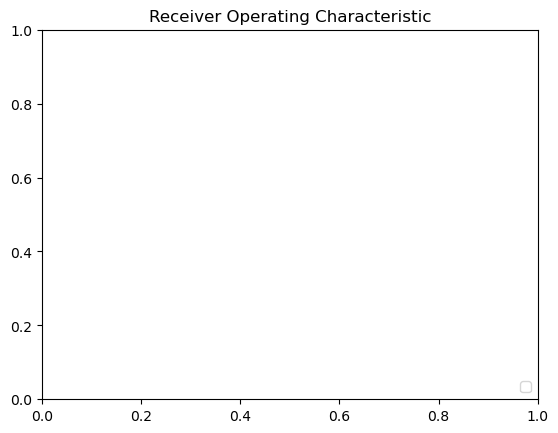

In [37]:
## Plot ROC AUC Curve
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure(figsize=(20,18))

# Add the models to the list that you want to view on the ROC plot
auc_models = [
{
    'label': 'Random Forest Classifier',
    'model': RandomForestClassifier(n_estimators=1000,min_samples_split=2,
                                          max_features=7,max_depth=None),
    'auc':  0.8332
},
{
    'label': 'Adaboost',
    'model': AdaBoostClassifier(n_estimators=90 , algorithm='SAMME'),
    'auc':  0.6089

},
{
    'label' : 'GradientBoost',
    'model' : GradientBoostingClassifier(n_estimators=1000 , loss='exponential' ,  learning_rate=1 , criterion='friedman_mse'),
    'auc' : 0.8532
},
{
    'label' : 'XGBoost',
    'model' : XGBClassifier(n_estimators=500, max_depth=7, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42),
    'auc' : 0.8837
}
    
]
# create loop through all model
for algo in auc_models:
    model = algo['model'] # select the model
    model.fit(x_train, y_train) # train the model
# Compute False postive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(x_test)[:,1])
# Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')

plt.ylabel('Sensitivity(True Positive Rate)')
plt.show() 

plt.title('Receiver Operating Characteristic')
plt.savefig("auc.png")
plt.legend(loc="lower right")

## Making Predictions on New Data Points

In [38]:
# First, check what unique values exist in categorical columns from training data
print("Unique values in training data for categorical features:")
print("\nOccupation:", x['Occupation'].unique())
print("\nGender:", x['Gender'].unique())
print("\nMaritalStatus:", x['MaritalStatus'].unique())
print("\nProductPitched:", x['ProductPitched'].unique())
print("\nTypeofContact:", x['TypeofContact'].unique())
print("\nDesignation:", x['Designation'].unique())

Unique values in training data for categorical features:

Occupation: ['Salaried' 'Free Lancer' 'Small Business' 'Large Business']

Gender: ['Female' 'Male']

MaritalStatus: ['Single' 'Divorced' 'Married' 'Unmarried']

ProductPitched: ['Deluxe' 'Basic' 'Standard' 'Super Deluxe' 'King']

TypeofContact: ['Self Enquiry' 'Company Invited']

Designation: ['Manager' 'Executive' 'Senior Manager' 'AVP' 'VP']


In [40]:
# Create new data points with VALID categories from training data
new_data = pd.DataFrame({
    'Age': [35, 45, 28],
    'Gender': ['Male', 'Female', 'Male'],
    'MaritalStatus': ['Married', 'Unmarried', 'Married'],
    'Occupation': ['Salaried', 'Salaried', 'Salaried'],  # Use only values from training data
    'ProductPitched': ['Basic', 'Deluxe', 'Standard'],
    'NumberOfFollowups': [3, 5, 2],
    'PreferredPropertyStar': [5, 3, 4],
    'NumberOfTrips': [2, 0, 3],
    'Passport': [1, 0, 1],
    'PitchSatisfactionScore': [3, 4, 5],
    'OwnCar': [0, 1, 1],
    'NumberOfChildrenVisiting': [1, 0, 2],
    'MonthlyIncome': [25000, 45000, 35000],
    'TypeofContact': ['Self Enquiry', 'Company Invited', 'Self Enquiry'],
    'DurationOfPitch': [15, 25, 20],
    'Designation': ['Executive', 'Manager', 'Executive'],
    'CityTier': [1, 2, 1],
    'TotalVisiting': [3, 1, 4]
})
# Employed
print("New Data Points:")
print(new_data)

New Data Points:
   Age  Gender MaritalStatus Occupation ProductPitched  NumberOfFollowups  \
0   35    Male       Married   Salaried          Basic                  3   
1   45  Female     Unmarried   Salaried         Deluxe                  5   
2   28    Male       Married   Salaried       Standard                  2   

   PreferredPropertyStar  NumberOfTrips  Passport  PitchSatisfactionScore  \
0                      5              2         1                       3   
1                      3              0         0                       4   
2                      4              3         1                       5   

   OwnCar  NumberOfChildrenVisiting  MonthlyIncome    TypeofContact  \
0       0                         1          25000     Self Enquiry   
1       1                         0          45000  Company Invited   
2       1                         2          35000     Self Enquiry   

   DurationOfPitch Designation  CityTier  TotalVisiting  
0               15   E

### Note: Unknown Category Error
If you get an error about unknown categories, it means the new data contains categorical values that weren't in the training data. Make sure all categorical values in new_data match those in the original training dataset.

In [41]:
# Apply the same preprocessing to new data
new_data_transformed = preprocessor.transform(new_data)
print("Transformed new data shape:", new_data_transformed.shape)
print(new_data_transformed)

Transformed new data shape: (3, 27)
[[ 1.          0.          1.          0.          1.          0.
   0.          0.          0.          1.          0.          0.
   1.          0.          0.          0.         -0.27705187 -0.7214003
  -0.05409302 -0.71872482  1.7670988  -0.61674205  1.58128038 -0.04901521
  -1.2771941   0.27601185 -0.77415132]
 [ 0.          0.          1.          0.          0.          1.
   0.          0.          0.          0.          0.          1.
   0.          1.          0.          0.          0.83358116  0.36682314
   1.13882125  1.28427877 -0.7268035  -1.67556156 -0.63239892  0.67968995
   0.78296635  4.07767062 -2.1919179 ]
 [ 1.          0.          1.          0.          1.          0.
   0.          1.          0.          1.          0.          0.
   1.          0.          0.          0.         -1.05449499 -0.7214003
   0.54236411 -1.72022662  0.52014765 -0.0873323   1.58128038  1.40839511
   0.78296635  2.17684124 -0.06526803]]


In [42]:
# Make predictions on new data
models={
    'rf_model' : RandomForestClassifier(n_estimators=1000, min_samples_split=2, 
                                    max_features=7, max_depth=None),
    'adaboost_model' : AdaBoostClassifier(n_estimators=90 , algorithm="SAMME"),
    'gradientBoost' : GradientBoostingClassifier(n_estimators=1000 , loss='exponential' ,  learning_rate=1 , criterion='friedman_mse'),
    'xgboost_model' : XGBClassifier(n_estimators=500, max_depth=7, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=42)

    }
for model in models.keys():

    models[model].fit(x_train, y_train)

    # Get predictions
    predictions = models[model].predict(new_data_transformed)
    prediction_proba = models[model].predict_proba(new_data_transformed)

    # Display results
    results_df = pd.DataFrame({
        'Customer': ['Customer 1', 'Customer 2', 'Customer 3'],
        'Prediction': predictions,
        'Will_Buy_Package': ['Yes' if pred == 1 else 'No' for pred in predictions],
        'Probability_No': prediction_proba[:, 0],
        'Probability_Yes': prediction_proba[:, 1]
    })

    print("\n" + "="*70)
    print(f'PREDICTION RESULTS {model}')
    print("="*70)
    print(results_df.to_string(index=False))
    print("="*70)



PREDICTION RESULTS rf_model
  Customer  Prediction Will_Buy_Package  Probability_No  Probability_Yes
Customer 1           1              Yes           0.473            0.527
Customer 2           0               No           0.669            0.331
Customer 3           1              Yes           0.462            0.538

PREDICTION RESULTS adaboost_model
  Customer  Prediction Will_Buy_Package  Probability_No  Probability_Yes
Customer 1           0               No        0.537067         0.462933
Customer 2           0               No        0.640282         0.359718
Customer 3           0               No        0.528555         0.471445

PREDICTION RESULTS gradientBoost
  Customer  Prediction Will_Buy_Package  Probability_No  Probability_Yes
Customer 1           1              Yes    1.319988e-08           1.0000
Customer 2           0               No    9.698001e-01           0.0302
Customer 3           1              Yes    9.924706e-11           1.0000

PREDICTION RESULTS xgboos